%pip install -r requirements.txt

# Import des librairies fondamentales
import pandas as pd
import numpy as np
import time
# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
# Prétraitement
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
# Modèles
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import lightgbm as lgb
import xgboost as xgb
import catboost as ctb
# Métriques
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score, f1_score
# Ignorer les avertissements
import warnings
warnings.filterwarnings('ignore')
print('Librairies importées avec succès !')

In [9]:
# Chargement du dataset
df = pd.read_csv('dataset_scoring_credit_900k.csv')
print(f'Le dataset contient {df.shape[0]:,} lignes et {df.shape[1]} colonnes.')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'dataset_scoring_credit_900k.csv'

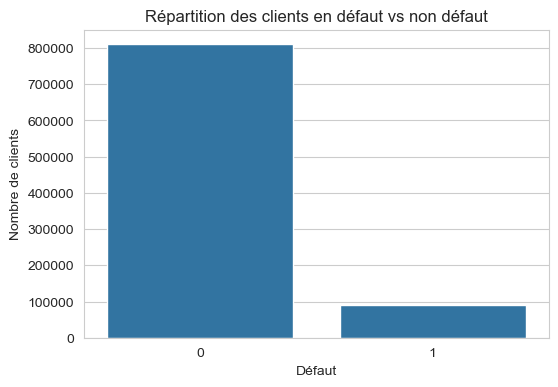

Taux de défaut : 0.1


In [ ]:
#Analyse de la variable cible
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="DEFAUT")
plt.title("Répartition des clients en défaut vs non défaut")
plt.xlabel("Défaut")
plt.ylabel("Nombre de clients")
plt.show()
print("Taux de défaut :", df["DEFAUT"].mean())

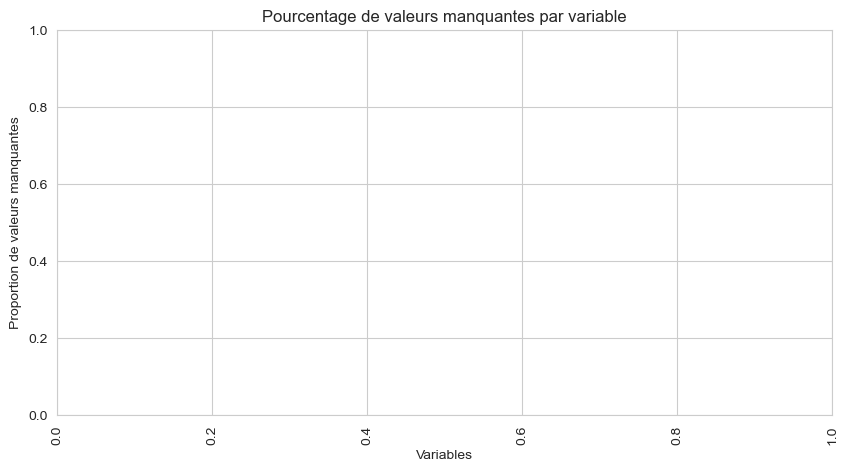

In [ ]:
#Analyse des valeurs manquantes
missing = df.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]
plt.figure(figsize=(10,5))
sns.barplot(x=missing.index, y=missing.values)
plt.title("Pourcentage de valeurs manquantes par variable")
plt.ylabel("Proportion de valeurs manquantes")
plt.xlabel("Variables")
plt.xticks(rotation=90)
plt.show()

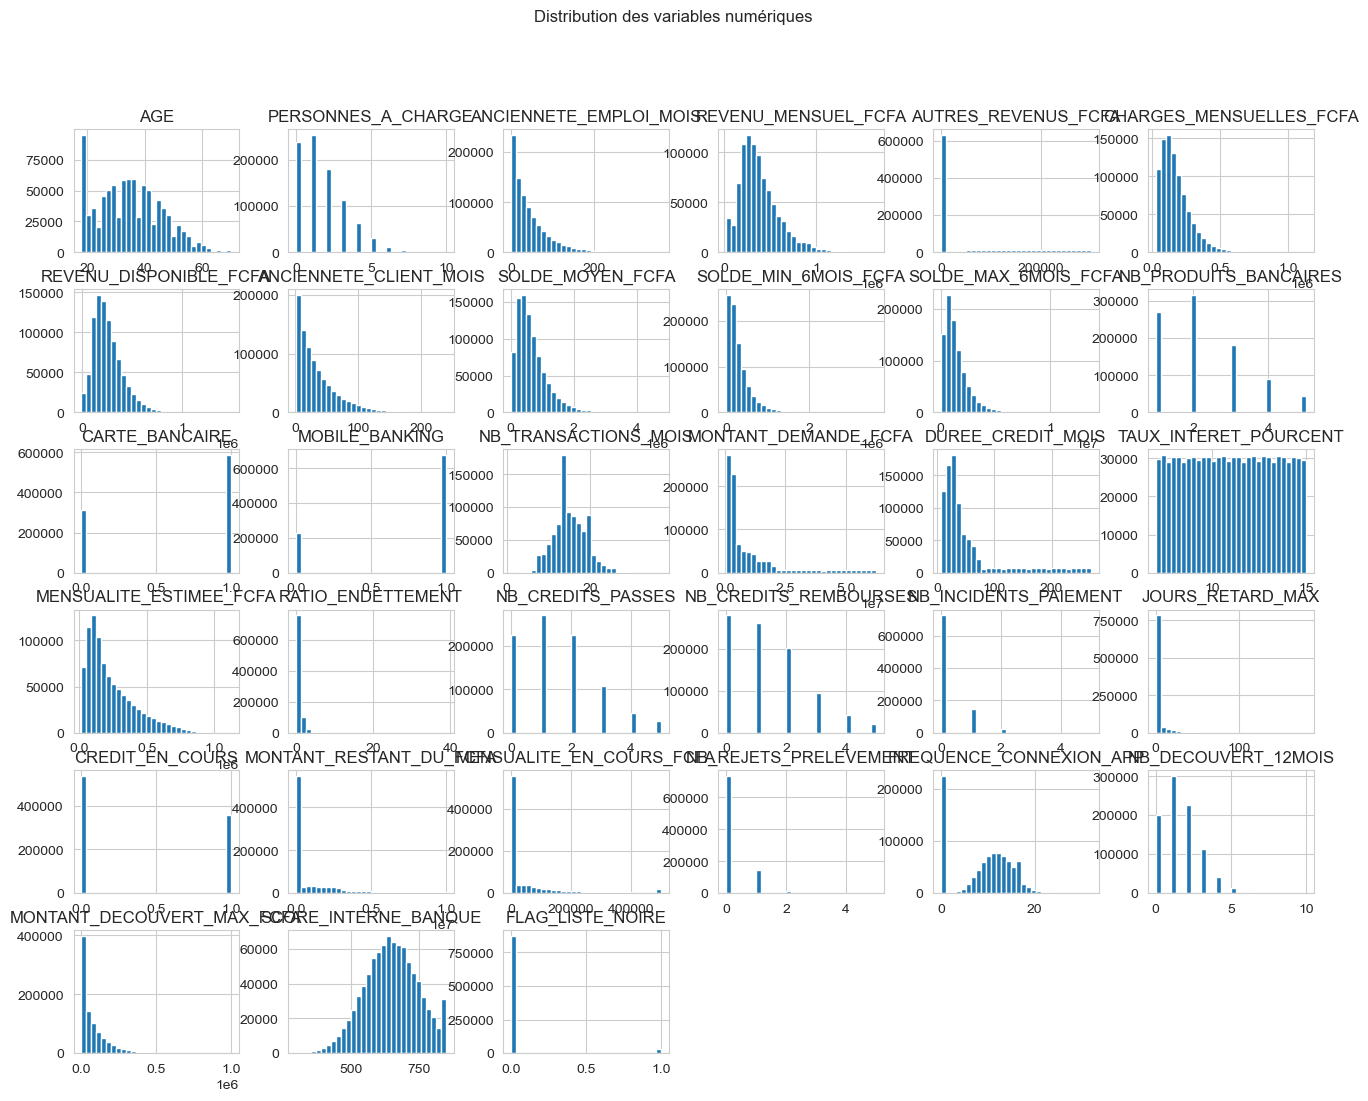

In [ ]:
#Distribution des variables numériques
num_cols = df.select_dtypes(include=["int64","float64"]).columns.drop("DEFAUT")
df[num_cols].hist(figsize=(16,12), bins=30)
plt.suptitle("Distribution des variables numériques")
plt.show()

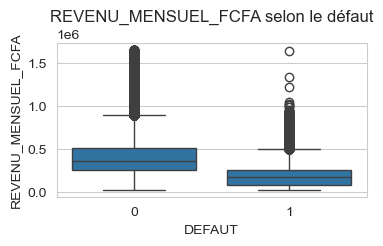

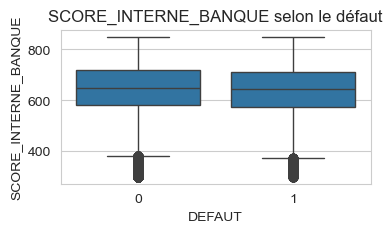

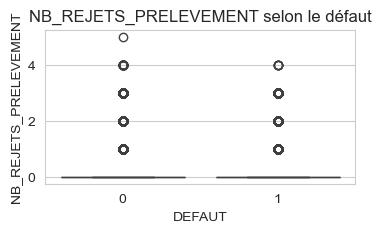

In [ ]:
#Comparaison des variables selon le défaut
important_vars = [
 "REVENU_MENSUEL_FCFA",
 "MONTANT_CREDIT_FCFA",
 "TAUX_ENDETTEMENT",
 "SCORE_INTERNE_BANQUE",
 "NB_REJETS_PRELEVEMENT",
 "NB_DECOUVERT_12MO"
 ]

for col in important_vars:
    if col in df.columns:
     plt.figure(figsize=(4,2))
     sns.boxplot(data=df, x="DEFAUT", y=col)
     plt.title(f"{col} selon le défaut")
     plt.show()

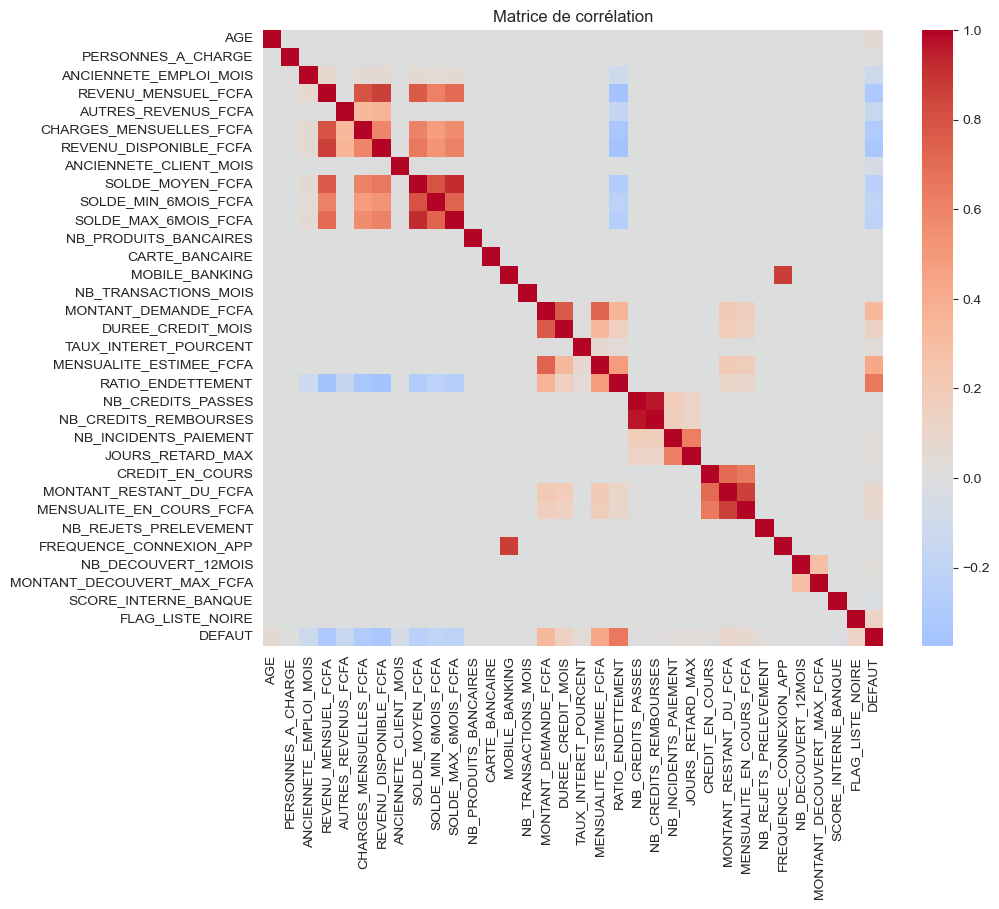

In [ ]:
#Analyse des corrélations
corr = df.select_dtypes(include=["int64","float64"]).corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matrice de corrélation")
plt.show()

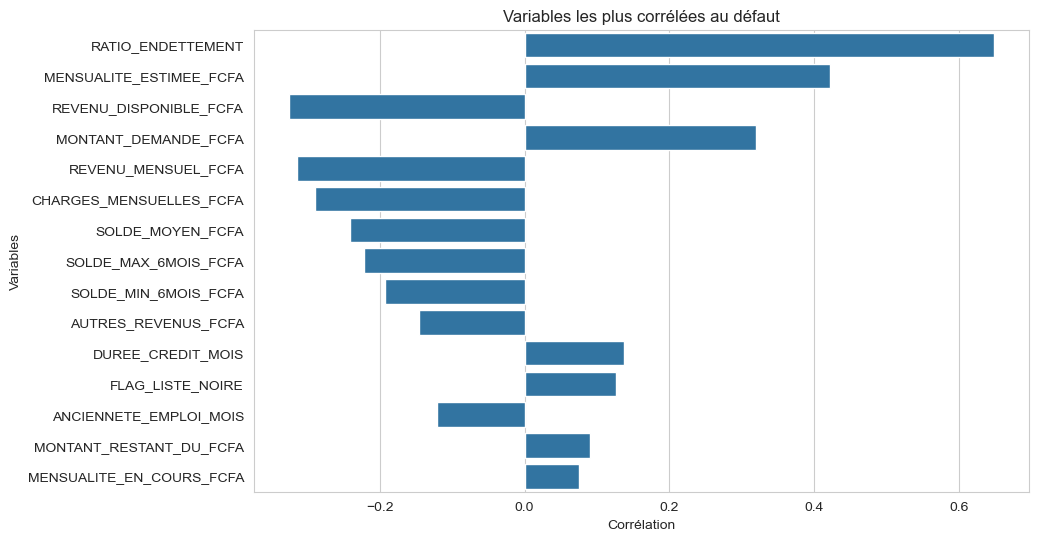

In [ ]:
#Variables les plus liées au défaut
corr_target = corr["DEFAUT"].drop("DEFAUT").sort_values(key=abs, ascending=False)
    
plt.figure(figsize=(10,6))
sns.barplot(x=corr_target.values[:15], y=corr_target.index[:15])
plt.title("Variables les plus corrélées au défaut")
plt.xlabel("Corrélation")
plt.ylabel("Variables")
plt.show()

In [ ]:
# Séparation de la variable cible (y) et des prédicteurs (X)
X = df.drop(['CLIENT_ID', 'DEFAUT'], axis=1)
y = df['DEFAUT']
# Identification des colonnes numériques et catégorielles
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns
# Création du pipeline de prétraitement
preprocessor = ColumnTransformer(
 transformers=[
 ('num', StandardScaler(), numerical_cols),
 ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
 ], remainder='passthrough'
)
# Séparation des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Taille du jeu d'entraînement : {X_train.shape[0]:,} lignes")
print(f"Taille du jeu de test : {X_test.shape[0]:,} lignes")

Taille du jeu d'entraînement : 720,000 lignes
Taille du jeu de test : 180,000 lignes


In [ ]:
# Dictionnaire pour stocker Les modèles et Leurs pipelines 
models = {
    'Régression Logistique': LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1, n_estimators=150, max_depth=15),
    'LightGBN': lgb.LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1, n_estimators=200),
    'XGBoost': xgb.XGBClassifier(random_state=42, scale_pos_weight=(len(y_train) - y_train.sum()) / y_train.sum(), use_label_encoder=False, eval_metric='logloss'),
    'SVM': SVC(random_state=42, class_weight='balanced', probability=True)
}
pipelines = {name: Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)]) for name, model in models.items()}
# Entraînement des modèles
results = {}
for name, pipeline in pipelines.items():
 start_time = time.time()
 print(f' Entraînement du modèle : {name}...', end=' ')

 # Cas spécial pour le SVM
 if name == 'SVM':
     # On prend un échantillon stratifié de 1%
     X_train_sample, _, y_train_sample, _ = train_test_split(X_train, y_train, train_size=0.01, random_state=42, stratify=y_train)
     pipeline.fit(X_train_sample, y_train_sample)
 else:
     pipeline.fit(X_train, y_train)

 end_time = time.time()
 training_time = end_time - start_time
 results[name] = {'pipeline': pipeline, 'training_time': training_time}
 print(f' Terminé en {training_time:.2f} secondes.')

 Entraînement du modèle : Régression Logistique...  Terminé en 11.25 secondes.
 Entraînement du modèle : Random Forest...  Terminé en 287.63 secondes.
 Entraînement du modèle : LightGBN...  Terminé en 36.18 secondes.
 Entraînement du modèle : XGBoost...  Terminé en 26.45 secondes.
 Entraînement du modèle : SVM...  Terminé en 6.78 secondes.


In [ ]:
# Calcul des prédictions et des probabilités pour chaque modèle
for name, res in results.items():
 print(f'Calcul des prédictions pour {name}...', end=' ')
 pipeline = res['pipeline']
 res['y_pred'] = pipeline.predict(X_test)
 res['y_proba'] = pipeline.predict_proba(X_test)[:, 1]
 print('OK')

# Création d'un DataFrame pour comparer les résultats
comparison_data = []
for name, res in results.items():
 comparison_data.append({
 'Modèle': name,
 'AUC': roc_auc_score(y_test, res['y_proba']),
 'Rappel (Défaut)': recall_score(y_test, res['y_pred']),
 'Précision (Défaut)': precision_score(y_test, res['y_pred']),
 'F1-Score (Défaut)': f1_score(y_test, res['y_pred']),
 'Temps Entraînement (s)': res['training_time']
 })
comparison_df = pd.DataFrame(comparison_data).sort_values(by='AUC', ascending=False).reset_index(drop=True)

# Affichage du tableau comparatif
display(comparison_df.style.background_gradient(cmap='viridis', subset=['AUC', 'Rappel (Défaut)', 'F1-Score (Défaut)']))

Calcul des prédictions pour Régression Logistique... OK
Calcul des prédictions pour Random Forest... OK
Calcul des prédictions pour LightGBN... OK
Calcul des prédictions pour XGBoost... OK
Calcul des prédictions pour SVM... OK


,Modèle,AUC,Rappel (Défaut),Précision (Défaut),F1-Score (Défaut),Temps Entraînement (s)
0,Régression Logistique,0.999870,0.999944,0.857790,0.923428,11.249268
1,LightGBN,0.999633,0.999389,0.828375,0.905882,36.181169
2,XGBoost,0.999623,0.996278,0.874482,0.931415,26.446867
3,SVM,0.998094,0.966222,0.867648,0.914286,6.784169
4,Random Forest,0.994920,0.964778,0.737723,0.836110,287.633805


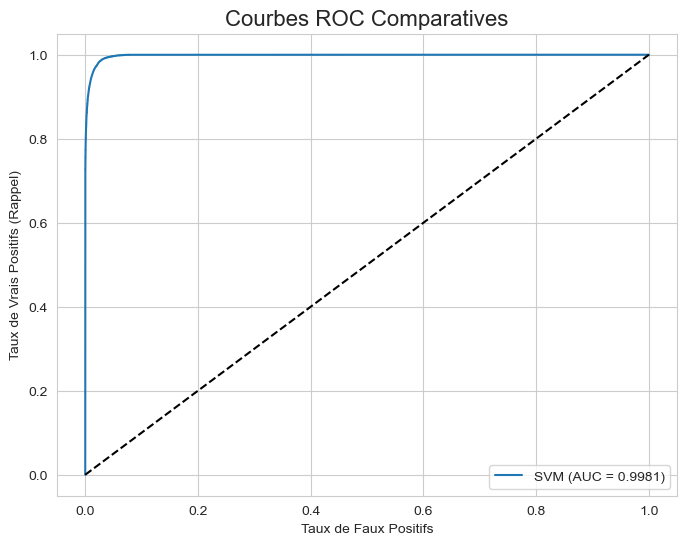

In [ ]:
# Visualisation des courbes ROC pour tous les modèles
plt.figure(figsize=(8, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
auc = roc_auc_score(y_test, res['y_proba'])
plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Courbes ROC Comparatives', fontsize=16)
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs (Rappel)')
plt.legend()
plt.show()

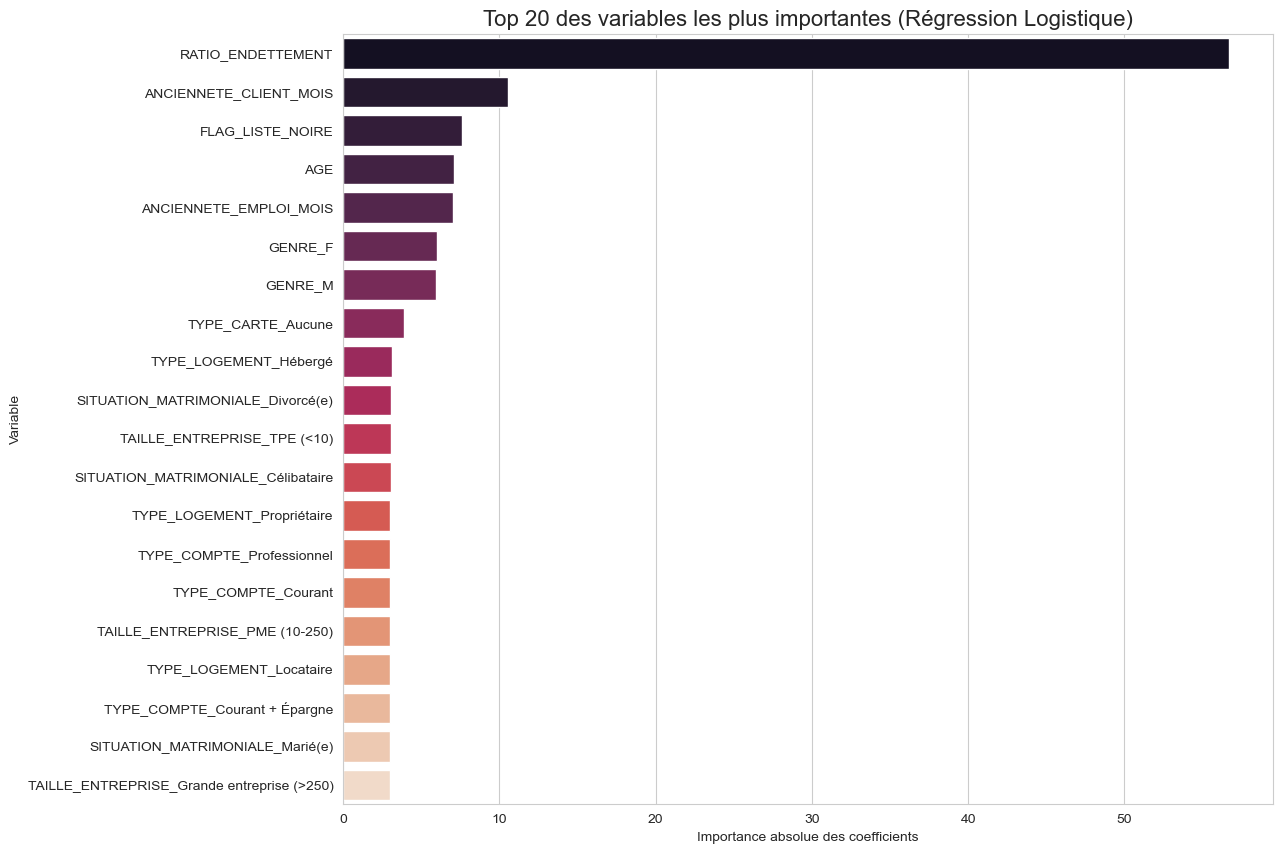

In [ ]:
# Extraction du pipeline et du modèle Régression Logistique
best_model_name = 'Régression Logistique'
best_pipeline = results[best_model_name]['pipeline']
best_model = best_pipeline.named_steps['classifier']
# Extraction des noms des features après prétraitement
ohe_feature_names = best_pipeline.named_steps['preprocessor'] \
 .named_transformers_['cat'] \
 .get_feature_names_out(categorical_cols)
all_feature_names = np.concatenate([numerical_cols, ohe_feature_names])
# Création du DataFrame des coefficients
feature_importance_df = pd.DataFrame({
 'feature': all_feature_names,
 'importance': np.abs(best_model.coef_[0])
}).sort_values('importance', ascending=False)
# Affichage du Top 20
plt.figure(figsize=(12, 10))
sns.barplot(
 x='importance',
 y='feature',
 data=feature_importance_df.head(20),
 hue='feature',
 legend=False,
 palette='rocket'
)
plt.title(f'Top 20 des variables les plus importantes ({best_model_name})', fontsize=16)
plt.xlabel("Importance absolue des coefficients")
plt.ylabel("Variable")
plt.show()